In [1]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from sklearn.model_selection import GroupShuffleSplit 
from sklearn.preprocessing import RobustScaler 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

I0000 00:00:1780408121.402951   45078 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
df = pd.read_csv("Data_Clean.csv")
df['tanggal_nabung'] = pd.to_datetime(df['tanggal_nabung'])
df = df.sort_values(by=['id_tabungan', 'tanggal_nabung'])

selesai_ids = df[df['status'] == 'Selesai']['id_tabungan'].unique()
df_train = df[df['id_tabungan'].isin(selesai_ids)].copy()

total_langkah = df_train.groupby('id_tabungan')['counter_tabungan'].transform('max')
df_train['sisa_kali_nabung'] = total_langkah - df_train['counter_tabungan']

df_train['sisa_nominal'] = df_train['target_nominal'] - df_train['total_terkumpul']
df_train['rumus_kalkulator'] = np.ceil(df_train['sisa_nominal'] / (df_train['nominal_nabung'] + 1)) 

df_train['persentase_target'] = (df_train['total_terkumpul'] / df_train['target_nominal']) * 100

fitur_x = [
    'target_nominal', 'nominal_nabung', 'total_terkumpul', 
    'jarak_hari_nabung', 'sisa_nominal', 'rumus_kalkulator',
    'persentase_target' 
]

print(f"Total baris data untuk training: {len(df_train)}")
print(f"Jumlah fitur sekarang: {len(fitur_x)}")

Total baris data untuk training: 24202
Jumlah fitur sekarang: 7


In [3]:
scaler_x = RobustScaler()
df_train[fitur_x] = scaler_x.fit_transform(df_train[fitur_x])

scaler_filename = "scaler_lstm.pkl"
joblib.dump(scaler_x, scaler_filename)
print(f"💾 Scaler X berhasil di-fit dan disimpan sebagai: {scaler_filename}")

💾 Scaler X berhasil di-fit dan disimpan sebagai: scaler_lstm.pkl


In [4]:
SEQ_LENGTH = 5

def create_sequences(data, seq_length, feature_cols, target_col):
    xs, ys, groups = [], [], []
    
    for id_tab, group in data.groupby('id_tabungan'):
        group_features = group[feature_cols].values
        group_target = group[target_col].values
        
        for i in range(len(group)):
            if i < seq_length - 1:
                pad_size = seq_length - 1 - i
                pad = np.zeros((pad_size, len(feature_cols)))
                seq = np.vstack([pad, group_features[:i+1]])
            else:
                seq = group_features[i - seq_length + 1 : i + 1]
                
            xs.append(seq)
            ys.append(group_target[i])
            groups.append(id_tab) 
            
    return np.array(xs), np.array(ys), np.array(groups) 

X, y_raw, groups_array = create_sequences(df_train, SEQ_LENGTH, fitur_x, 'sisa_kali_nabung')

scaler_y = RobustScaler()
y_scaled = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

joblib.dump(scaler_y, "scaler_y_lstm.pkl")
print("💾 Scaler Y berhasil di-fit dan disimpan sebagai: scaler_y_lstm.pkl")

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y_scaled, groups=groups_array))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_scaled[train_idx], y_scaled[test_idx]

print(f"Bentuk Input X_train : {X_train.shape} -> (Sampel, Time_Steps, Fitur)")
print(f"Bentuk Target y_train: {y_train.shape}")

💾 Scaler Y berhasil di-fit dan disimpan sebagai: scaler_y_lstm.pkl
Bentuk Input X_train : (19188, 5, 7) -> (Sampel, Time_Steps, Fitur)
Bentuk Target y_train: (19188,)


In [5]:
inputs = layers.Input(shape=(SEQ_LENGTH, len(fitur_x)), name="lstm_input")

x = layers.Masking(mask_value=0.0)(inputs)
x = layers.LSTM(128, return_sequences=True)(x)
x = layers.Dropout(0.2)(x)
x = layers.LSTM(64, return_sequences=False)(x)
x = layers.Dense(32, activation='relu')(x)

outputs = layers.Dense(1, activation='linear', name="estimasi_output")(x)

model_lstm = Model(inputs=inputs, outputs=outputs, name="LSTM_Behavioral_Fixed")

model_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001), 
    loss='mse', 
    metrics=['mae']
)

model_lstm.summary()

W0000 00:00:1780408125.869585   45078 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "LSTM_Behavioral_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lstm_input          │ (None, 5, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 5, 7)      │          0 │ lstm_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 5, 7)      │          0 │ lstm_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 5)         │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 5, 128)    │     69,632 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 5, 128)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ estimasi_output     │ (None, 1)         │         33 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 121,153 (473.25 KB)

 Trainable params: 121,153 (473.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
class TargetTercapaiCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('mae') is not None and logs.get('mae') < 0.05:
            print(f"\n[Custom Callback] Epoch {epoch+1}: MAE mencapai target (< 0.05)! Menghentikan proses training.")
            self.model.stop_training = True

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

custom_early_stop = TargetTercapaiCallback()

print("Memulai Training LSTM...")
history = model_lstm.fit(
    X_train, y_train,
    epochs=100, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr, custom_early_stop],
    verbose=1
)

Memulai Training LSTM...
Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0444 - mae: 0.1062 - val_loss: 0.0130 - val_mae: 0.0745 - learning_rate: 0.0010
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0147 - mae: 0.0726 - val_loss: 0.0105 - val_mae: 0.0667 - learning_rate: 0.0010
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0123 - mae: 0.0681 - val_loss: 0.0115 - val_mae: 0.0700 - learning_rate: 0.0010
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0112 - mae: 0.0653 - val_loss: 0.0114 - val_mae: 0.0698 - learning_rate: 0.0010
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0111 - mae: 0.0653 - val_loss: 0.0107 - val_mae: 0.0673 - learning_rate: 0.0010
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0103 - mae: 0.0646 - val_loss: 0.0114 - val_mae: 0.0673 - learning_rate: 0.0010
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0103 - mae: 0.0640 - val_loss: 0.0112 - val_mae: 0.074

   📊 SUMMARY EVALUASI PERFORMA MODEL AI - LSTM   

AKURASI PREDIKSI:
  • Skor Akurasi Model (R² Score) : 98.89%
  • Rata-rata Meleset (MAE)       : 1.24 kali nabung
  • Persentase Error (MAPE)       : 11.17%

PERFORMA DI LAPANGAN:
  • Prediksi 100% Tepat (Sempurna) : 35.80% dari total data uji


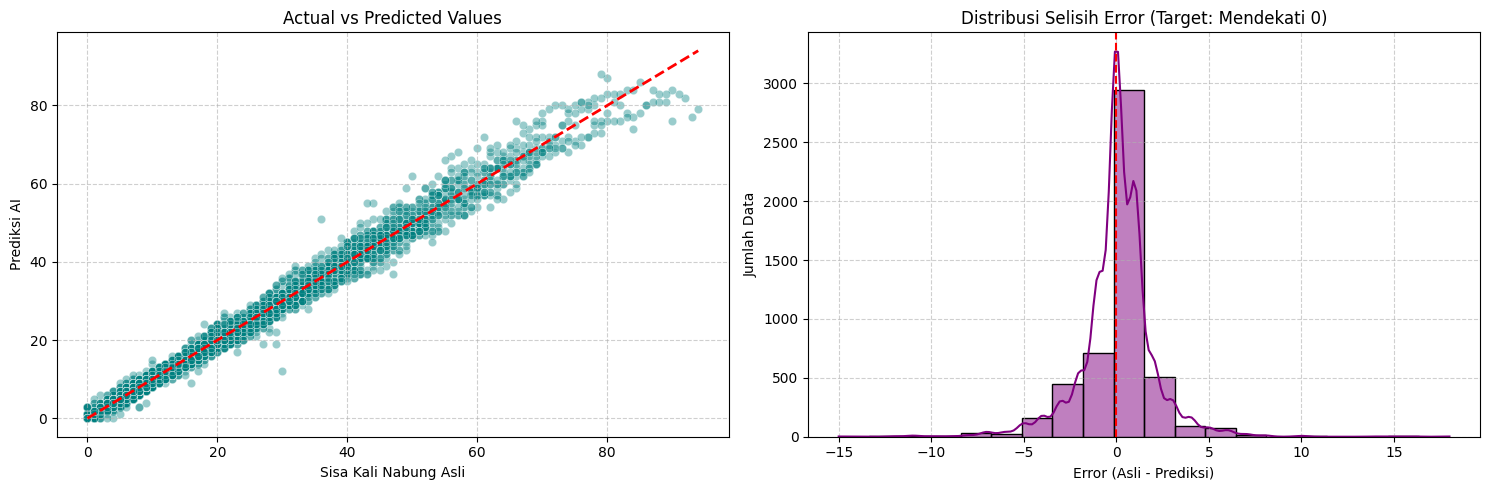

In [7]:
print("=" * 60)
print("   📊 SUMMARY EVALUASI PERFORMA MODEL AI - LSTM   ")
print("=" * 60)

scaler_y_loaded = joblib.load("scaler_y_lstm.pkl")
dl_preds_scaled = model_lstm.predict(X_test, verbose=0)

dl_preds_raw = scaler_y_loaded.inverse_transform(dl_preds_scaled).flatten()
dl_preds = np.round(dl_preds_raw)
dl_preds = np.clip(dl_preds, 0, None)

y_test_asli = scaler_y_loaded.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae = mean_absolute_error(y_test_asli, dl_preds)
non_zero_mask = y_test_asli != 0
mape = np.mean(np.abs((y_test_asli[non_zero_mask] - dl_preds[non_zero_mask]) / y_test_asli[non_zero_mask])) * 100
r2 = r2_score(y_test_asli, dl_preds)

residuals = y_test_asli - dl_preds
akurasi_sempurna = (residuals == 0).sum() / len(residuals) * 100

print(f"\nAKURASI PREDIKSI:")
print(f"  • Skor Akurasi Model (R² Score) : {r2*100:.2f}%")
print(f"  • Rata-rata Meleset (MAE)       : {mae:.2f} kali nabung")
print(f"  • Persentase Error (MAPE)       : {mape:.2f}%")

print(f"\nPERFORMA DI LAPANGAN:")
print(f"  • Prediksi 100% Tepat (Sempurna) : {akurasi_sempurna:.2f}% dari total data uji")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(x=y_test_asli, y=dl_preds, alpha=0.4, ax=axes[0], color='teal')
axes[0].plot([y_test_asli.min(), y_test_asli.max()], [y_test_asli.min(), y_test_asli.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted Values')
axes[0].set_xlabel('Sisa Kali Nabung Asli')
axes[0].set_ylabel('Prediksi AI')
axes[0].grid(True, linestyle='--', alpha=0.6)

sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=20)
axes[1].axvline(x=0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Distribusi Selisih Error (Target: Mendekati 0)')
axes[1].set_xlabel('Error (Asli - Prediksi)')
axes[1].set_ylabel('Jumlah Data')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [8]:
model_filename = "model_lstm_tabungan.keras"
model_lstm.save(model_filename)
print(f"💾 Model berhasil disimpan sebagai: {model_filename}")

💾 Model berhasil disimpan sebagai: model_lstm_tabungan.keras


In [9]:
print("\n" + "="*70)
print("  UJI COBA PREDIKSI PRODUKSI BATCH (BANYAK PERCOBAAN)")
print("="*70)

model_filename = "model_lstm_tabungan.keras"
loaded_model = keras.models.load_model(model_filename)
loaded_scaler_x = joblib.load("scaler_lstm.pkl")
loaded_scaler_y = joblib.load("scaler_y_lstm.pkl")
SEQ_LENGTH = 5

skenario_list = [
    {
        "nama_user": "User A (Nabung Agresif)",
        "data": [
            [5000000, 500000, 500000, 0],   
            [5000000, 600000, 1100000, 7],  
            [5000000, 200000, 1300000, 30]  
        ]
    },
    {
        "nama_user": "User B (Nabung Konsisten)",
        "data": [
            [2000000, 200000, 200000, 0],
            [2000000, 200000, 400000, 7],
            [2000000, 200000, 600000, 7],
            [2000000, 200000, 800000, 7]
        ]
    },
    {
        "nama_user": "User C (Hampir Selesai, Target Besar)",
        "data": [
            [20000000, 5000000, 5000000, 0],
            [20000000, 4000000, 9000000, 30],
            [20000000, 9000000, 18000000, 15]
        ]
    }
]

batch_input = []

for skenario in skenario_list:
    df_histori = pd.DataFrame(
        skenario['data'], 
        columns=['target_nominal', 'nominal_nabung', 'total_terkumpul', 'jarak_hari_nabung']
    )
    
    df_histori['sisa_nominal'] = df_histori['target_nominal'] - df_histori['total_terkumpul']
    df_histori['rumus_kalkulator'] = np.ceil(df_histori['sisa_nominal'] / (df_histori['nominal_nabung'] + 1))
    df_histori['persentase_target'] = (df_histori['total_terkumpul'] / df_histori['target_nominal']) * 100
    
    riwayat_scaled = loaded_scaler_x.transform(df_histori)
    
    jumlah_padding = SEQ_LENGTH - len(riwayat_scaled)
    if jumlah_padding > 0:
        padding = np.zeros((jumlah_padding, len(df_histori.columns)))
        riwayat_final = np.vstack([padding, riwayat_scaled])
    else:
        riwayat_final = riwayat_scaled[-SEQ_LENGTH:]
        
    batch_input.append(riwayat_final)

input_tensor = np.array(batch_input) 

prediksi_scaled = loaded_model.predict(input_tensor, verbose=0)
prediksi_raw = loaded_scaler_y.inverse_transform(prediksi_scaled)

for i, skenario in enumerate(skenario_list):
    estimasi_kali_nabung = np.ceil(prediksi_raw[i][0])
    estimasi_final = max(1, estimasi_kali_nabung) 
    
    print(f"👤 {skenario['nama_user']}")
    print(f"   Riwayat diproses : {len(skenario['data'])} transaksi")
    print(f"   Total Terkumpul  : Rp {skenario['data'][-1][2]:,}")
    print(f"   Target           : Rp {skenario['data'][-1][0]:,}")
    print(f"   --> Prediksi AI  : Sekitar {estimasi_final} kali nabung lagi\n")


  UJI COBA PREDIKSI PRODUKSI BATCH (BANYAK PERCOBAAN)
👤 User A (Nabung Agresif)
   Riwayat diproses : 3 transaksi
   Total Terkumpul  : Rp 1,300,000
   Target           : Rp 5,000,000
   --> Prediksi AI  : Sekitar 10.0 kali nabung lagi

👤 User B (Nabung Konsisten)
   Riwayat diproses : 4 transaksi
   Total Terkumpul  : Rp 800,000
   Target           : Rp 2,000,000
   --> Prediksi AI  : Sekitar 6.0 kali nabung lagi

👤 User C (Hampir Selesai, Target Besar)
   Riwayat diproses : 3 transaksi
   Total Terkumpul  : Rp 18,000,000
   Target           : Rp 20,000,000
   --> Prediksi AI  : Sekitar 2.0 kali nabung lagi

